**Luz Marina Flores Carbajal**

# Modelo de predicción para consumo de combustible

## Entendimiento del negocio

1. Determinar los Objetivos del Negocio

En la industria automotriz, la eficiencia de combustible (medida en MPG) es un factor competitivo y ambiental crítico. El objetivo principal de este proyecto es optimizar el diseño del portafolio de vehículos estimando de manera rápida y precisa la eficiencia de combustible desde la fase de diseño técnico, reduciendo así los costos y la dependencia de costosas pruebas mecánicas físicas. El criterio de éxito para el negocio será desarrollar una herramienta predictiva con un margen de error lo suficientemente bajo como para integrarse de manera confiable en las etapas iniciales de ingeniería y pre-diseño.

2. Evaluar la Situación

Para llevar a cabo este proyecto contamos con el dataset "Auto MPG", que contiene información histórica y especificaciones técnicas de varios vehículos, y utilizaremos librerías especializadas de Python para el análisis. Partimos del supuesto de que las características físicas del motor (como peso y cilindrada) tienen una relación matemática directa con el consumo, aunque el modelo estará limitado a predecir el comportamiento de motores de combustión interna clásicos (1970-1982), dejando fuera tecnologías modernas como vehículos híbridos. El principal riesgo identificado es la presencia de datos faltantes en variables clave, para lo cual se aplicarán técnicas de imputación matemática o exclusión controlada como plan de contingencia.

3. Determinar los Objetivos de Minería de Datos

El objetivo técnico es construir un modelo de regresión supervisado capaz de predecir de forma continua el consumo de combustible a partir de los atributos físicos, identificando además cuáles son las variables mecánicas que tienen el mayor impacto en dicho rendimiento. Para considerar la fase de modelado como un éxito, se establecen como criterios técnicos lograr un Error Absoluto Medio (MAE) inferior a 2.5 MPG y obtener un coeficiente de determinación R² igual o superior a 0.80 en el conjunto de prueba, lo que garantizaría que el modelo explica la gran mayoría de la variabilidad del consumo.

4. Producir el Plan del Proyecto

El proyecto se ejecutará siguiendo de manera secuencial las fases de la metodología CRISP-DM. Tras esta primera etapa de definición estratégica, se procederá con el análisis exploratorio para entender la distribución y correlación de los datos, seguido de una fase de preparación que incluirá la limpieza de valores nulos y el escalado de características. Finalmente, se entrenarán y ajustarán múltiples algoritmos de regresión, se evaluará su rendimiento mediante validación cruzada y se documentarán las conclusiones clave para su futura implementación en los procesos de diseño automotriz.

## Entendimiento de los datos

### Colección o lectura de datos

En esta etapa de colección inicial, procederemos a cargar el conjunto de datos en nuestro entorno de trabajo utilizando la librería Pandas de Python. Dado que el archivo original no contiene los nombres de las variables, definiremos explícitamente la cabecera con los atributos identificados previamente (MPG, cilindros, cilindrada, caballos de fuerza, peso, aceleración, año, origen y nombre) para estructurar correctamente la información en un DataFrame. Esto nos permitirá manipular y acceder a los datos con facilidad en las siguientes celdas.

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Definir los nombres de las columnas
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                'acceleration', 'model_year', 'origin', 'car_name']

# Leer los datos usando sep='\s+' para versiones modernas de Pandas
# Y usando el nombre exacto del archivo que muestra la captura
df = pd.read_csv('auto-mpg.data-original', names=column_names, sep='\s+', na_values='NA')

# Mostrar las primeras filas para confirmar la lectura
display(df.head())

<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16264\863202540.py:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv('auto-mpg.data-original', names=column_names, sep='\s+', na_values='NA')


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0,chevrolet chevelle malibu
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,buick skylark 320
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,plymouth satellite
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,amc rebel sst
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,ford torino


Se importó con éxito el archivo histórico auto-mpg.data-original utilizando Pandas y configurando la expresión regular sep='\s+' para interpretar correctamente los espacios en blanco como delimitadores. El dataset fue estructurado en un DataFrame de 406 registros y 9 columnas, asignando de manera correcta las etiquetas de las variables mecánicas y del vehículo.

### Descripción de datos

Examinaremos la estructura general del DataFrame que acabamos de generar. Esto incluye revisar el número total de registros, los tipos de variables de cada columna (identificando cuáles son numéricas continuas, discretas o de texto) y obtener estadísticas descriptivas básicas como promedios, desviaciones estándar y cuartiles. Este paso es fundamental para confirmar que la importación se realizó correctamente y tener un primer panorama cuantitativo de las especificaciones de los vehículos

In [112]:
# Información general de los tipos de datos y valores no nulos
print("--- Información del DataFrame ---")
df.info()

print("\n--- Estadísticas Descriptivas ---")
# Resumen estadístico de las variables numéricas
display(df.describe())

--- Información del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     406 non-null    float64
 2   displacement  406 non-null    float64
 3   horsepower    400 non-null    float64
 4   weight        406 non-null    float64
 5   acceleration  406 non-null    float64
 6   model_year    406 non-null    float64
 7   origin        406 non-null    float64
 8   car_name      406 non-null    str    
dtypes: float64(8), str(1)
memory usage: 28.7 KB

--- Estadísticas Descriptivas ---


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,406.000000,406.000000,400.000000,406.000000,406.000000,406.000000,406.000000
mean,23.514573,5.475369,194.779557,105.082500,2979.413793,15.519704,75.921182,1.568966
std,7.815984,1.712160,104.922458,38.768779,847.004328,2.803359,3.748737,0.797479
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,105.000000,75.750000,2226.500000,13.700000,73.000000,1.000000
50%,23.000000,4.000000,151.000000,95.000000,2822.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,302.000000,130.000000,3618.250000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


El conjunto de datos consta de 406 filas y 9 columnas. Contamos con 8 variables numéricas continuas o discretas (de tipo float64) y una sola variable categórica de texto (car_name). A nivel estadístico, destaca que la variable objetivo mpg (millas por galón) presenta una media de 23.51 MPG, oscilando entre un mínimo de 9 MPG (vehículos muy ineficientes) y un máximo de 46.6 MPG. Asimismo, el peso de los vehículos (weight) varía de manera drástica en el dataset, yendo desde las 1,613 hasta las 5,140 libras, lo que sugiere una amplia diversidad en el tipo de automóviles evaluados.

- mpg (Millas por galón): Variable numérica continua y objetivo principal (target) del modelo. Mide la eficiencia del consumo de combustible del vehículo en un ciclo de manejo urbano.

- cylinders (Cilindros): Variable numérica discreta. Indica la cantidad de cilindros que componen el bloque del motor (por ejemplo: motores de 3, 4, 5, 6 u 8 cilindros).

- displacement (Cilindrada): Variable numérica continua. Mide el volumen total de desplazamiento de los pistones dentro de los cilindros del motor, expresado en pulgadas cúbicas. Representa el tamaño físico del motor.

- horsepower (Caballos de fuerza): Variable numérica continua. Representa la potencia mecánica neta que genera el motor. Es el atributo que identificamos originalmente con 6 valores faltantes.

- weight (Peso): Variable numérica continua. Indica la masa total del automóvil medida en libras americanas.

- acceleration (Aceleración): Variable numérica continua. Mide el tiempo exacto, medido en segundos, que le toma al vehículo acelerar de 0 a 60 millas por hora (el equivalente aproximado a pasar de 0 a 100 km/h).

- model_year (Año del modelo): Variable numérica discreta. Registra el año de fabricación del automóvil utilizando los últimos dos dígitos del año cronológico (donde el valor 70 representa 1970 y 82 corresponde a 1982).

- origin (Origen): Variable numérica discreta. Es un código categórico que identifica la región geográfica del fabricante original del vehículo (donde 1 equivale a Norteamérica, 2 a Europa y 3 a Asia).

- car_name (Nombre del automóvil): Cadena de texto (string). Funciona como una etiqueta identificadora única para cada registro, combinando la marca comercial y el modelo específico del vehículo.

### Exploración de datos

In [113]:
df.shape

(406, 9)

Análisis visual detallado para descubrir patrones, tendencias y relaciones iniciales entre nuestras variables. Generaremos una matriz de correlación para observar de manera rápida cómo interactúan mecánicamente características como el peso, la cilindrada o la aceleración con nuestra variable objetivo (MPG). Estos hallazgos visuales nos darán indicios muy fuertes sobre cuáles atributos serán los predictores más robustos para nuestro futuro modelo de machine learning.

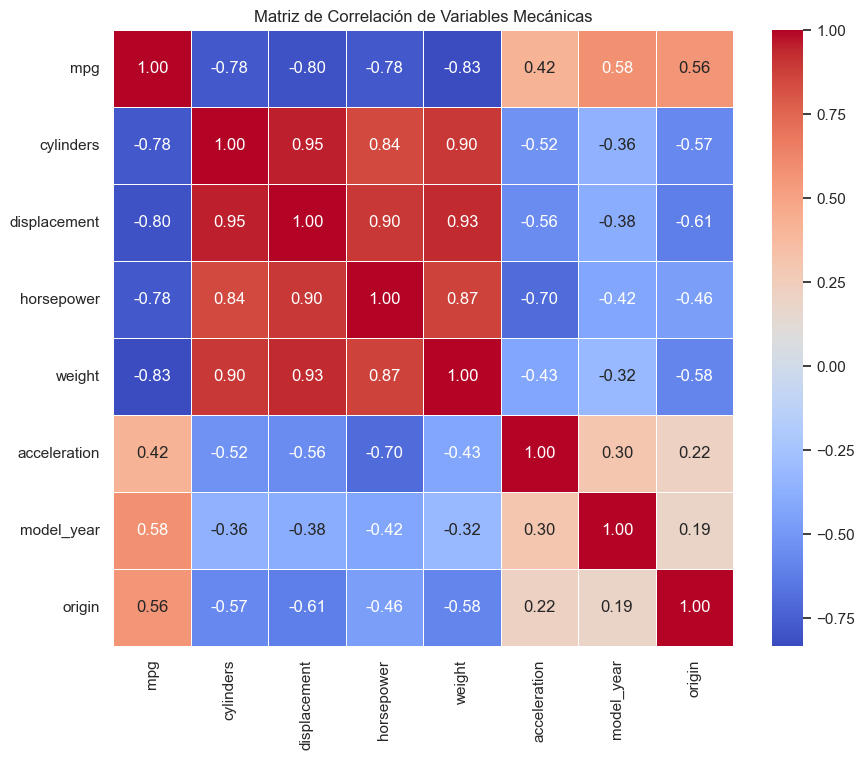

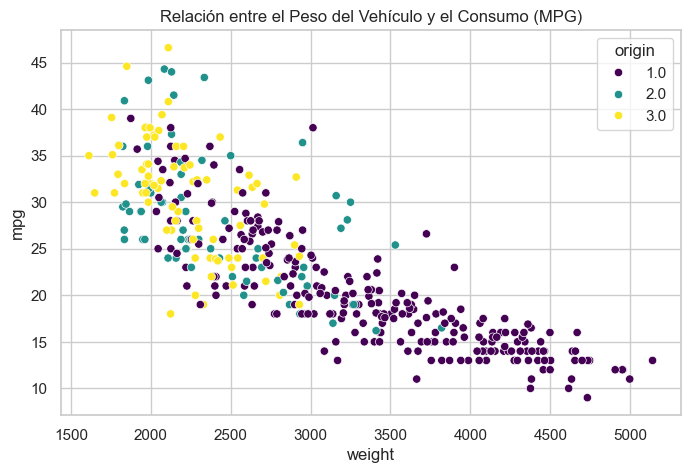

In [114]:
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear una matriz de correlación (excluyendo la columna de texto 'car_name')
plt.figure(figsize=(10, 8))
correlation_matrix = df.drop('car_name', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Mecánicas')
plt.show()

# Gráfico de dispersión entre el peso y el consumo (MPG)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='weight', y='mpg', hue='origin', palette='viridis')
plt.title('Relación entre el Peso del Vehículo y el Consumo (MPG)')
plt.show()

A través del análisis gráfico y correlacional, se extraen dos conclusiones críticas para nuestro futuro modelo:
- Fuertes correlaciones negativas: La eficiencia de combustible (mpg) tiene una altísima correlación inversa con el peso del vehículo (weight con $-0.83$), la cilindrada (displacement con $-0.80$), la cantidad de cilindros (cylinders con $-0.78$) y los caballos de fuerza (horsepower con $-0.78$). Esto demuestra matemáticamente que a mayor peso, tamaño y potencia del motor, el rendimiento de combustible cae drásticamente.
- Comportamiento no lineal y segmentación geográfica: El gráfico de dispersión revela que la relación entre el peso (weight) y el rendimiento (mpg) no es estrictamente lineal, sino que describe una curva de decaimiento exponencial. Además, se aprecia una clara segmentación por origen: los vehículos de origen 1.0 (Norteamérica, puntos morados) dominan el sector de autos pesados y de bajo rendimiento, mientras que los de origen 2.0 (Europa) y 3.0 (Asia) se concentran en el espectro de vehículos ligeros y altamente eficientes.

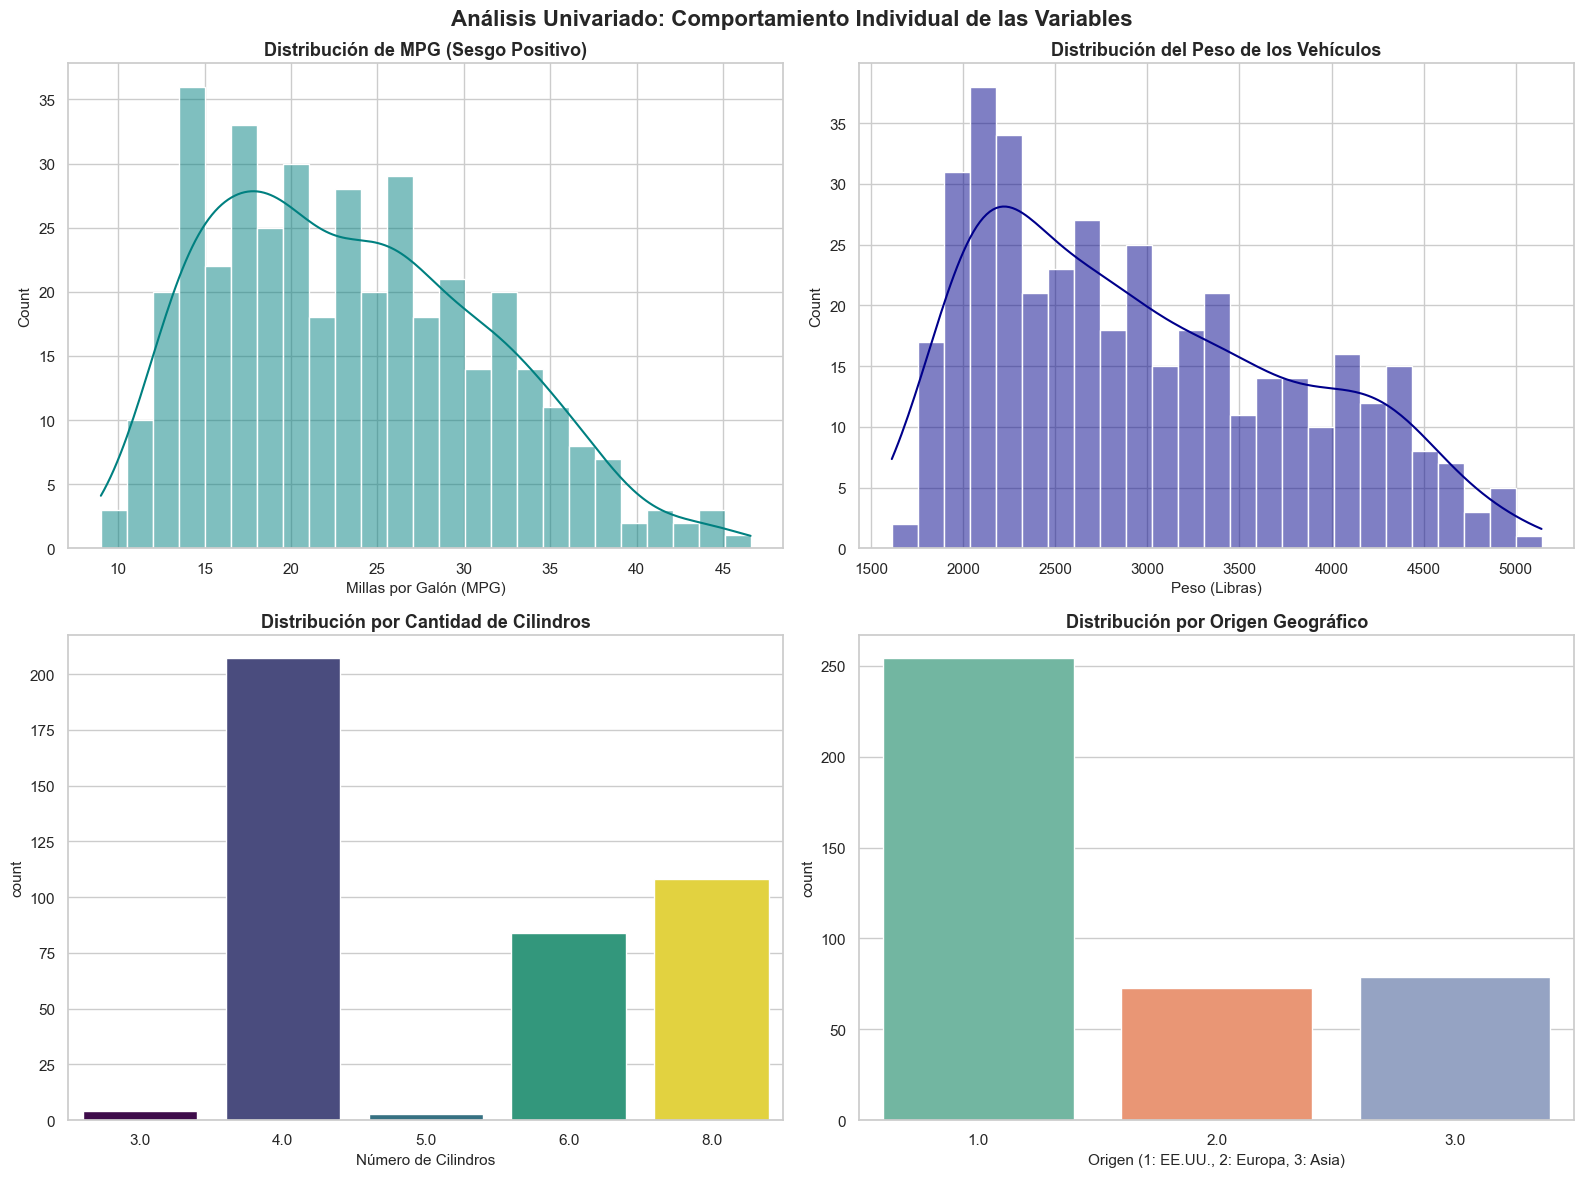

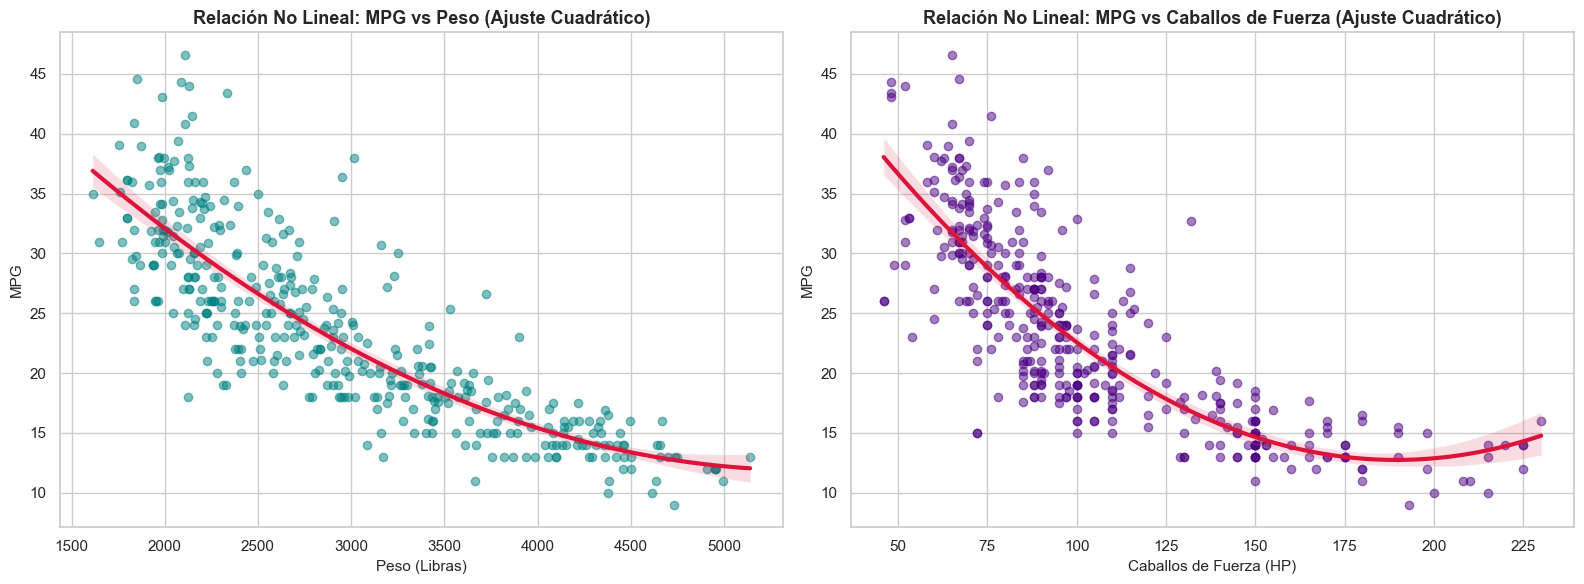

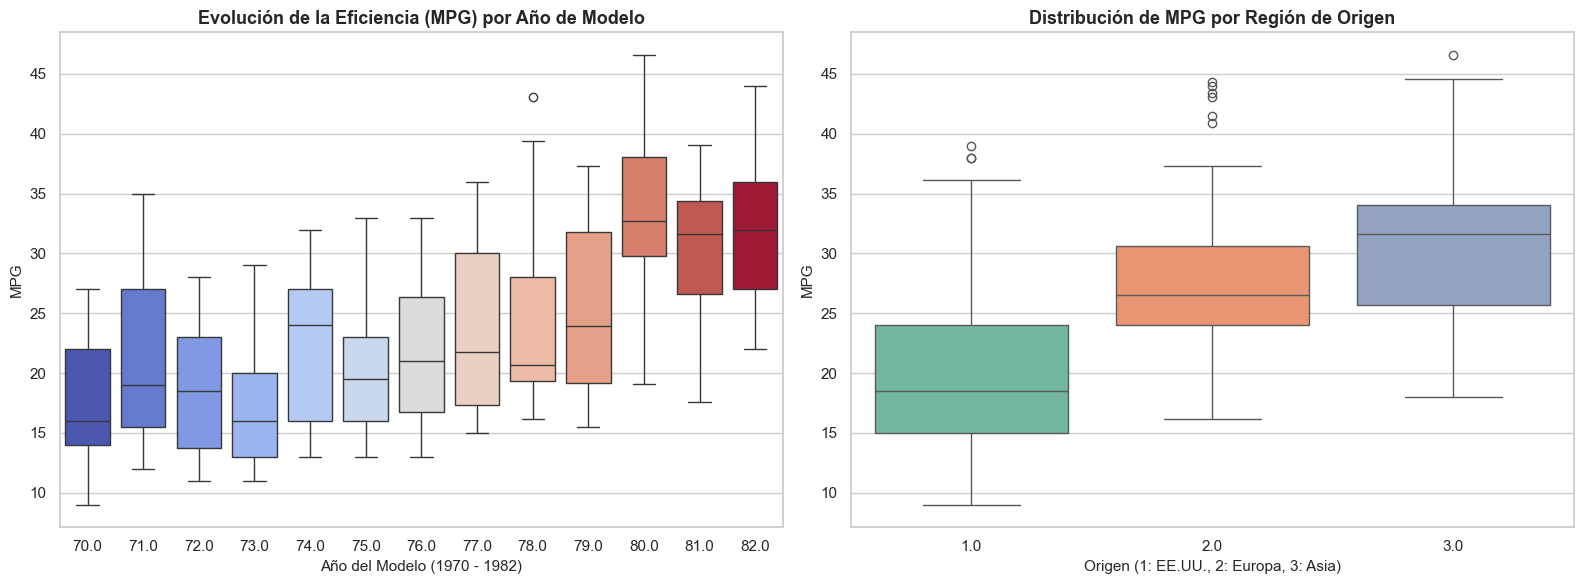

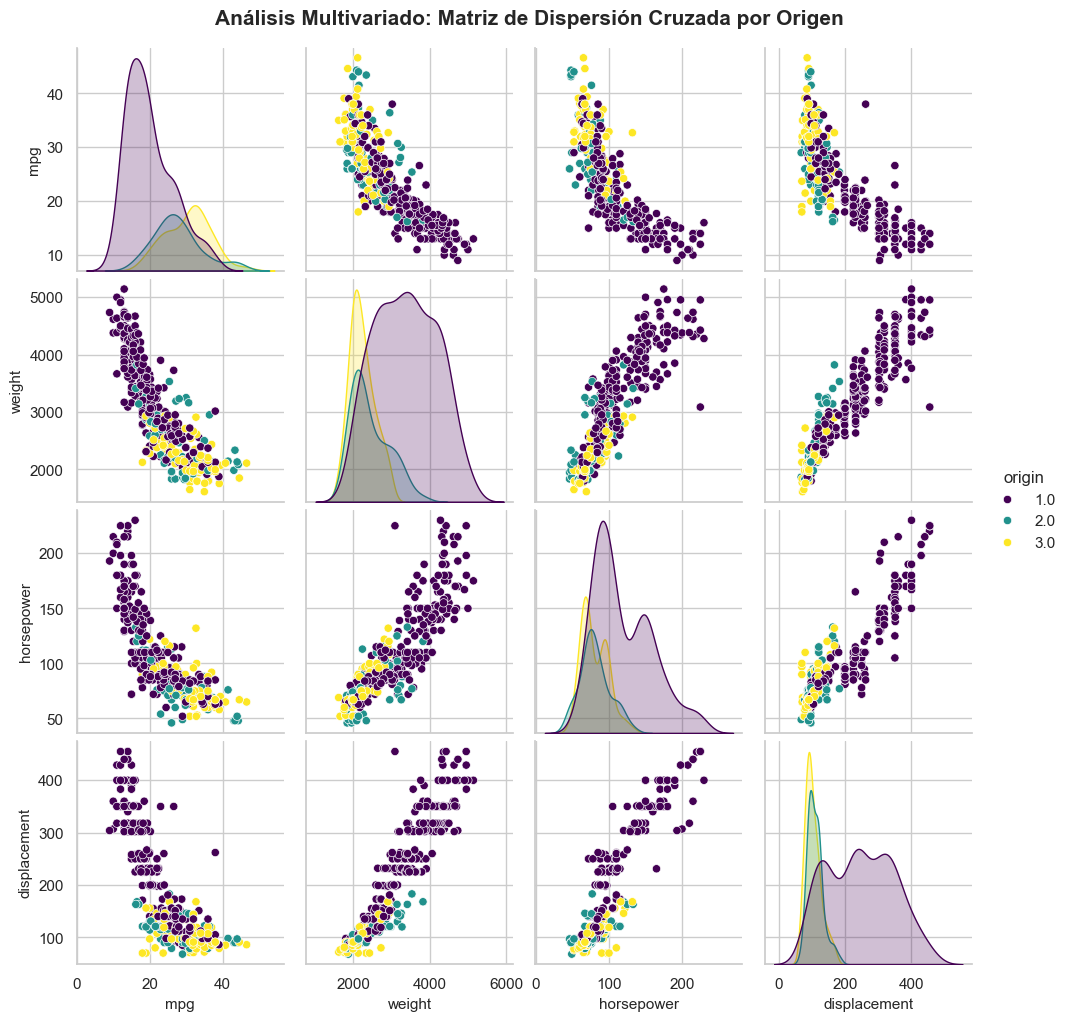

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética general
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13

# =====================================================================
# 1. ANÁLISIS UNIVARIADO: Distribuciones de variables clave
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribución de la Variable Objetivo (MPG)
sns.histplot(df['mpg'].dropna(), kde=True, ax=axes[0, 0], color='teal', bins=25)
axes[0, 0].set_title('Distribución de MPG (Sesgo Positivo)', fontweight='bold')
axes[0, 0].set_xlabel('Millas por Galón (MPG)')

# Distribución de la variable Peso (Weight)
sns.histplot(df['weight'], kde=True, ax=axes[0, 1], color='darkblue', bins=25)
axes[0, 1].set_title('Distribución del Peso de los Vehículos', fontweight='bold')
axes[0, 1].set_xlabel('Peso (Libras)')

# Distribución de Cilindros (Discreta)
sns.countplot(data=df, x='cylinders', ax=axes[1, 0], hue='cylinders', palette='viridis', legend=False)
axes[1, 0].set_title('Distribución por Cantidad de Cilindros', fontweight='bold')
axes[1, 0].set_xlabel('Número de Cilindros')

# Distribución de Origen
sns.countplot(data=df, x='origin', ax=axes[1, 1], hue='origin', palette='Set2', legend=False)
axes[1, 1].set_title('Distribución por Origen Geográfico', fontweight='bold')
axes[1, 1].set_xlabel('Origen (1: EE.UU., 2: Europa, 3: Asia)')

plt.suptitle('Análisis Univariado: Comportamiento Individual de las Variables', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


# =====================================================================
# 2. ANÁLISIS BIVARIADO: Relaciones físicas no lineales con el Target
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ajuste cuadrático para Peso vs MPG (La física del consumo no es lineal)
sns.regplot(data=df, x='weight', y='mpg', ax=axes[0], order=2,
            scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'crimson', 'linewidth': 3})
axes[0].set_title('Relación No Lineal: MPG vs Peso (Ajuste Cuadrático)', fontweight='bold')
axes[0].set_xlabel('Peso (Libras)')
axes[0].set_ylabel('MPG')

# Ajuste cuadrático para Caballos de Fuerza vs MPG
temp_df = df.dropna(subset=['horsepower'])
sns.regplot(data=temp_df, x='horsepower', y='mpg', ax=axes[1], order=2,
            scatter_kws={'alpha':0.5, 'color':'indigo'}, line_kws={'color':'crimson', 'linewidth': 3})
axes[1].set_title('Relación No Lineal: MPG vs Caballos de Fuerza (Ajuste Cuadrático)', fontweight='bold')
axes[1].set_xlabel('Caballos de Fuerza (HP)')
axes[1].set_ylabel('MPG')

plt.tight_layout()
plt.show()


# =====================================================================
# 3. ANÁLISIS SEGMENTADO: Impacto del Tiempo y la Geografía
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Evolución del rendimiento por año de fabricación
sns.boxplot(data=df, x='model_year', y='mpg', ax=axes[0], hue='model_year', palette='coolwarm', legend=False)
axes[0].set_title('Evolución de la Eficiencia (MPG) por Año de Modelo', fontweight='bold')
axes[0].set_xlabel('Año del Modelo (1970 - 1982)')
axes[0].set_ylabel('MPG')

# Rendimiento por Origen Geográfico
sns.boxplot(data=df, x='origin', y='mpg', ax=axes[1], hue='origin', palette='Set2', legend=False)
axes[1].set_title('Distribución de MPG por Región de Origen', fontweight='bold')
axes[1].set_xlabel('Origen (1: EE.UU., 2: Europa, 3: Asia)')
axes[1].set_ylabel('MPG')

plt.tight_layout()
plt.show()


# =====================================================================
# 4. ANÁLISIS MULTIVARIADO: Interacciones cruzadas por Origen
# =====================================================================
# Seleccionamos las columnas continuas clave para evitar sobrecargar el gráfico
features_to_plot = ['mpg', 'weight', 'horsepower', 'displacement', 'origin']
sns.pairplot(df[features_to_plot].dropna(), hue='origin', palette='viridis', diag_kind='kde', height=2.5)
plt.suptitle('Análisis Multivariado: Matriz de Dispersión Cruzada por Origen', y=1.02, fontsize=15, fontweight='bold')
plt.show()

- Rendimiento (mpg): Observé que la variable objetivo presenta un claro sesgo positivo (hacia la derecha). Esto significa que la mayor concentración de vehículos de esa época se encuentra en rangos de eficiencia bajos a moderados (entre 15 y 28 MPG), mientras que los vehículos altamente eficientes (más de 35 MPG) son casos más raros y selectos en mi muestra.

- Peso (weight): Al analizar esta distribución, detecté una estructura casi bimodal con un sesgo hacia la derecha. Identifiqué un pico muy fuerte en el rango de las 2,000 a 2,300 libras (autos compactos ligeros), pero la curva se extiende de forma prolongada hasta superar las 5,000 libras, confirmando que tengo una buena cantidad de vehículos pesados en el set de datos.

- Cilindros (cylinders): Esta variable se comporta de forma puramente discreta. Noté que el grupo más masivo con diferencia es el de 4 cilindros (superando los 200 autos), seguido por los motores potentes de 8 cilindros y los de 6 cilindros. Las configuraciones de 3 y 5 cilindros son prácticamente inexistentes, por lo que tendré que tratarlas con cuidado al modelar.

- Origen Geográfico (origin): Constaté que existe un fuerte desbalance en mi muestra. Los autos de origen 1.0 (Norteamérica) dominan de manera absoluta con más de 250 registros, mientras que los mercados de origen 2.0 (Europa) y 3.0 (Asia) están empatados en una proporción mucho menor (alrededor de 70 a 80 registros cada uno).

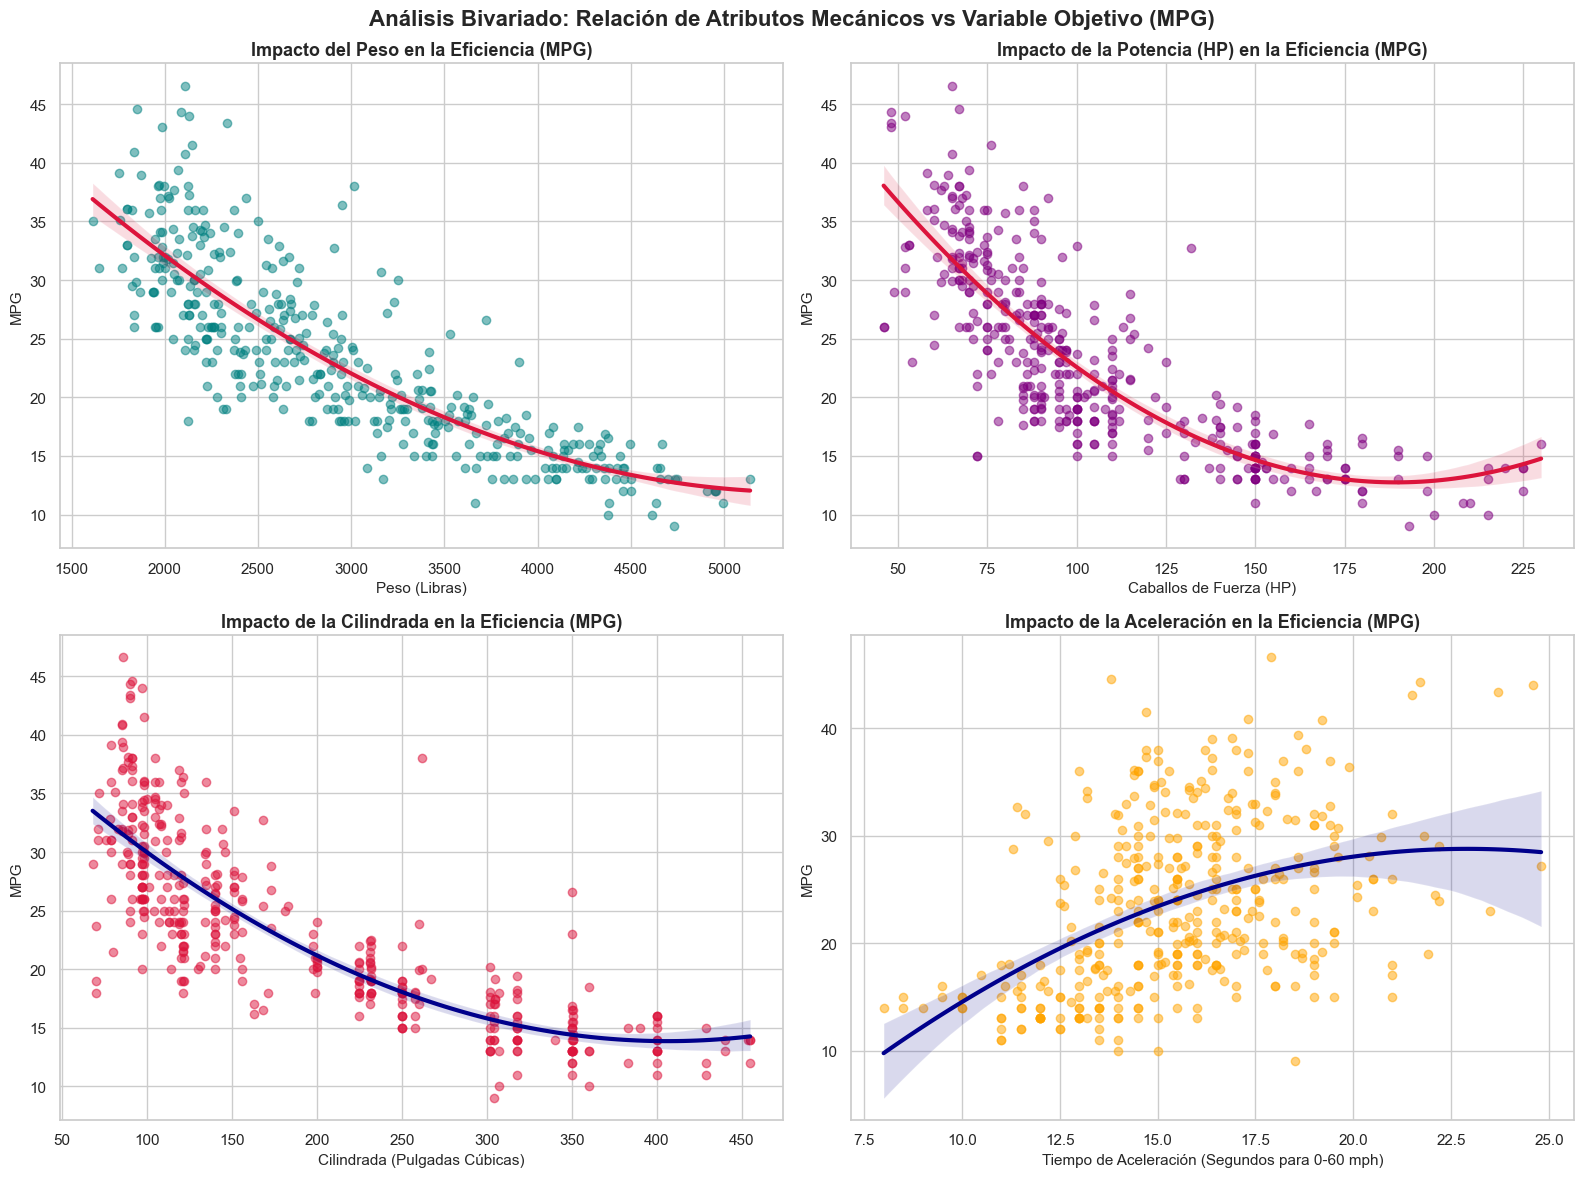

In [116]:
# Se importa el módulo de gráficos de la librería Matplotlib para configurar el lienzo
import matplotlib.pyplot as plt
# Se carga la librería Seaborn para la construcción de los gráficos estadísticos avanzados
import seaborn as sns

# Se inicializa un lienzo de gráficos de 2 filas por 2 columnas con un tamaño de 16x12 pulgadas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Relación entre el Peso y las Millas por Galón
# Se traza un gráfico de dispersión y regresión de segundo orden (cuadrática) para capturar la tendencia no lineal
sns.regplot(data=df, x='weight', y='mpg', ax=axes[0, 0], order=2,
            scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'crimson', 'linewidth': 3})
# Se asigna el título formal al gráfico situado en la posición superior izquierda
axes[0, 0].set_title('Impacto del Peso en la Eficiencia (MPG)', fontweight='bold')
# Se rotula el eje horizontal indicando la variable predictora (Peso en libras)
axes[0, 0].set_xlabel('Peso (Libras)')
# Se rotula el eje vertical indicando la variable objetivo (Millas por Galón)
axes[0, 0].set_ylabel('MPG')

# Gráfico 2: Relación entre los Caballos de Fuerza y las Millas por Galón
# Se eliminan temporalmente los valores nulos de la columna horsepower para evitar errores en el ajuste matemático
df_hp_clean = df.dropna(subset=['horsepower'])
# Se traza la regresión cuadrática entre los caballos de fuerza y el rendimiento de combustible
sns.regplot(data=df_hp_clean, x='horsepower', y='mpg', ax=axes[0, 1], order=2,
            scatter_kws={'alpha':0.5, 'color':'purple'}, line_kws={'color':'crimson', 'linewidth': 3})
# Se asigna el título formal al gráfico situado en la posición superior derecha
axes[0, 1].set_title('Impacto de la Potencia (HP) en la Eficiencia (MPG)', fontweight='bold')
# Se rotula el eje horizontal para la variable de caballos de fuerza
axes[0, 1].set_xlabel('Caballos de Fuerza (HP)')
# Se rotula el eje vertical para la variable objetivo
axes[0, 1].set_ylabel('MPG')

# Gráfico 3: Relación entre la Cilindrada y las Millas por Galón
# Se construye el gráfico de dispersión con ajuste curvo para la cilindrada del motor
sns.regplot(data=df, x='displacement', y='mpg', ax=axes[1, 0], order=2,
            scatter_kws={'alpha':0.5, 'color':'crimson'}, line_kws={'color':'darkblue', 'linewidth': 3})
# Se asigna el título formal al gráfico situado en la posición inferior izquierda
axes[1, 0].set_title('Impacto de la Cilindrada en la Eficiencia (MPG)', fontweight='bold')
# Se rotula el eje horizontal especificando la unidad de medida (pulgadas cúbicas)
axes[1, 0].set_xlabel('Cilindrada (Pulgadas Cúbicas)')
# Se rotula el eje vertical para mantener la consistencia con el target
axes[1, 0].set_ylabel('MPG')

# Gráfico 4: Relación entre la Aceleración y las Millas por Galón
# Se analiza el comportamiento del tiempo de aceleración frente al rendimiento de combustible
sns.regplot(data=df, x='acceleration', y='mpg', ax=axes[1, 1], order=2,
            scatter_kws={'alpha':0.5, 'color':'orange'}, line_kws={'color':'darkblue', 'linewidth': 3})
# Se asigna el título formal al gráfico situado en la posición inferior derecha
axes[1, 1].set_title('Impacto de la Aceleración en la Eficiencia (MPG)', fontweight='bold')
# Se rotula el eje horizontal denotando que la aceleración se mide en el tiempo de respuesta (segundos)
axes[1, 1].set_xlabel('Tiempo de Aceleración (Segundos para 0-60 mph)')
# Se rotula el eje vertical para la variable objetivo
axes[1, 1].set_ylabel('MPG')

# Se define un título principal y unificado para todo el panel bivariado desarrollado
plt.suptitle('Análisis Bivariado: Relación de Atributos Mecánicos vs Variable Objetivo (MPG)', fontsize=16, fontweight='bold', y=0.98)
# Se ejecuta el ajuste automático de márgenes para impedir el solapamiento de textos o etiquetas
plt.tight_layout()
# Se renderiza y despliega el panel de gráficos finalizado en el cuaderno de trabajo
plt.show()

- Impacto del Peso en la Eficiencia: Se constata una clara relación inversa de carácter no lineal. Existe una alta densidad de vehículos ligeros (entre 1,500 y 2,700 libras) que logran los rangos de eficiencia más altos del dataset, llegando a superar las 40 MPG. Sin embargo, a medida que el peso se incrementa hacia las 3,500 libras, la dispersión se reduce notablemente y la curva de ajuste de segundo orden decae de forma parabólica, forzando a los vehículos pesados (superiores a 4,000 libras) a estancarse en una franja crítica de bajo rendimiento, entre las 10 y 15 MPG.

- Impacto de la Potencia (HP) y Efecto de Borde: El comportamiento de los caballos de fuerza refleja una penalización drástica en el rendimiento conforme aumenta la potencia. No obstante, se detecta un fenómeno matemático particular en el extremo derecho del gráfico (entre 190 y 230 HP): la curva de ajuste cuadrático muestra una leve inflexión hacia arriba. Esto no responde a una ganancia real de eficiencia en vehículos hiper-potentes, sino a un artefacto estadístico del modelo polinomial de segundo grado al intentar ajustarse a la baja densidad de puntos en ese extremo (efecto de palanca), un detalle clave que se deberá considerar al elegir el algoritmo de predicción final.

- Impacto de la Cilindrada y Discretización Estructural: La relación entre la cilindrada y las MPG confirma un decaimiento parabólico similar al del peso, pero con una característica visual única: los datos se agrupan en franjas o líneas verticales bien definidas (por ejemplo, alrededor de las 100, 250, 300 y 350 pulgadas cúbicas). Esto demuestra que la cilindrada, a pesar de ser una variable continua, responde a estándares de manufactura industrial específicos de la época (tamaños de motor estandarizados por los fabricantes). La curva tiende a estabilizarse por completo al alcanzar las 400 pulgadas cúbicas.

- Impacto de la Aceleración y Variabilidad en los Extremos: Al ser la aceleración una medida de tiempo (segundos requeridos para alcanzar de 0 a 60 mph), se confirma una tendencia positiva: a mayor cantidad de segundos (motores más lentos), mayor es el rendimiento en MPG. Es crítico observar el ensanchamiento de la banda de sombreado azul (intervalo de confianza) en los extremos del gráfico, específicamente por debajo de los 10 segundos y por encima de los 22 segundos. Este comportamiento evidencia que el dataset posee muy pocos registros de vehículos con aceleraciones extremas (ya sean de alto desempeño deportivo o extremadamente lentos), lo que incrementa la incertidumbre matemática en esas zonas.

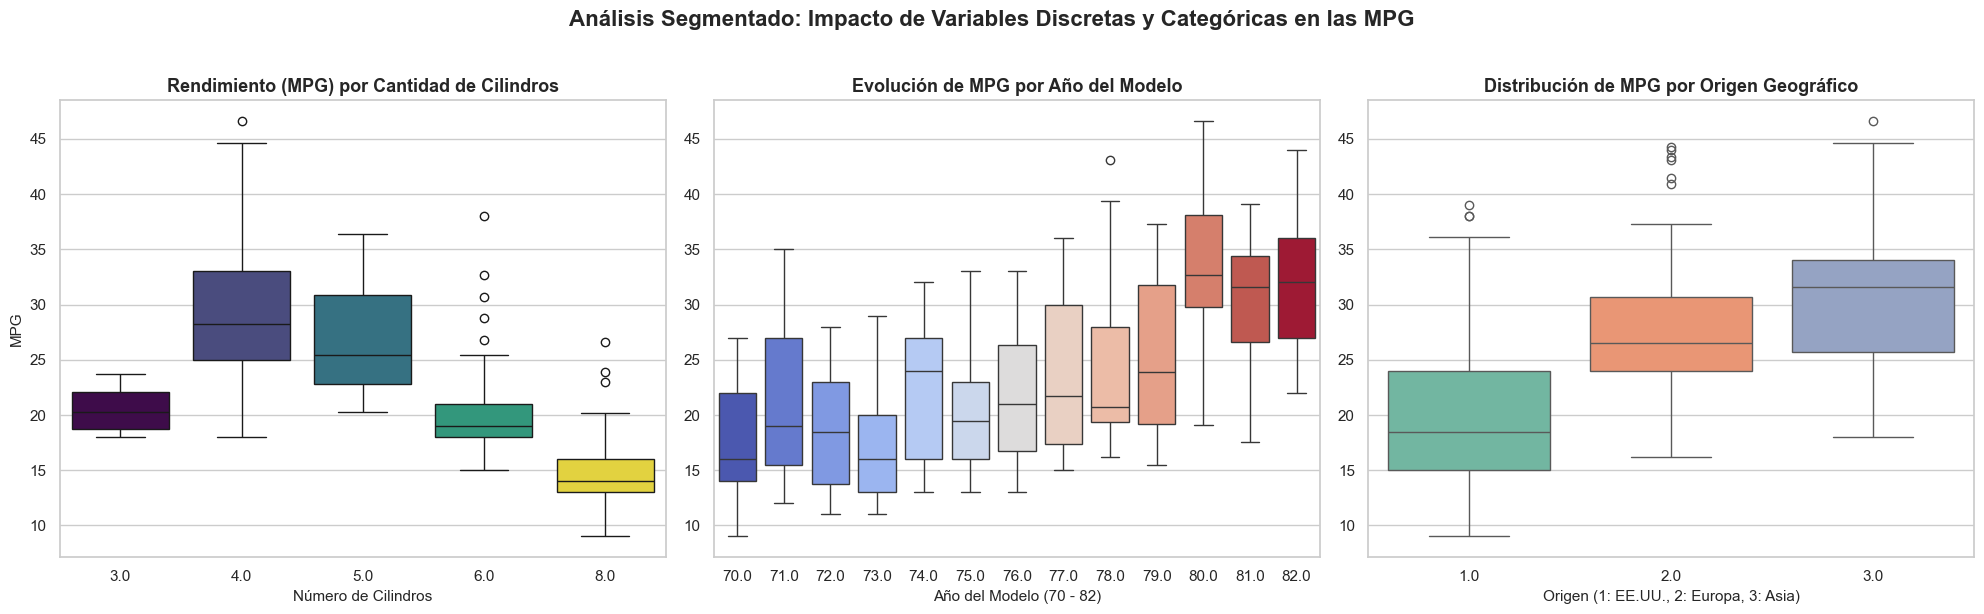

In [117]:
# Se importa Matplotlib para la gestión de las subgráficas y el lienzo general
import matplotlib.pyplot as plt
# Se carga Seaborn para la generación de los gráficos de cajas y bigotes (boxplots)
import seaborn as sns

# Se inicializa un lienzo con 1 fila y 3 columnas, definiendo un tamaño amplio de 20x6 pulgadas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: Distribución de MPG según la cantidad de Cilindros
# Se genera el boxplot ubicando los cilindros en el eje X y las millas por galón en el eje Y
sns.boxplot(data=df, x='cylinders', y='mpg', ax=axes[0], hue='cylinders', palette='viridis', legend=False)
# Se establece el título en negrita para el primer subgráfico de la izquierda
axes[0].set_title('Rendimiento (MPG) por Cantidad de Cilindros', fontweight='bold')
# Se etiqueta el eje horizontal para identificar los grupos de cilindros
axes[0].set_xlabel('Número de Cilindros')
# Se etiqueta el eje vertical para la variable objetivo
axes[0].set_ylabel('MPG')

# Gráfico 2: Distribución de MPG a lo largo de los Años del Modelo
# Se crea el gráfico de cajas para observar el comportamiento del consumo según el año de fabricación
sns.boxplot(data=df, x='model_year', y='mpg', ax=axes[1], hue='model_year', palette='coolwarm', legend=False)
# Se asigna el título en negrita al gráfico central del panel
axes[1].set_title('Evolución de MPG por Año del Modelo', fontweight='bold')
# Se rotula el eje X especificando que se evalúa la línea de tiempo
axes[1].set_xlabel('Año del Modelo (70 - 82)')
# Se remueve la etiqueta del eje Y para evitar redundancia visual en el panel central
axes[1].set_ylabel('')

# Gráfico 3: Distribución de MPG según el Origen Geográfico del vehículo
# Se construye el boxplot cruzando el origen codificado con la eficiencia de combustible
sns.boxplot(data=df, x='origin', y='mpg', ax=axes[2], hue='origin', palette='Set2', legend=False)
# Se define el título en negrita para el tercer subgráfico de la derecha
axes[2].set_title('Distribución de MPG por Origen Geográfico', fontweight='bold')
# Se rotula el eje horizontal detallando el significado de la codificación numérica
axes[2].set_xlabel('Origen (1: EE.UU., 2: Europa, 3: Asia)')
# Se elimina la etiqueta del eje Y para mantener la limpieza visual en el extremo derecho
axes[2].set_ylabel('')

# Se añade un título principal y descriptivo en la parte superior de todo el lienzo integrado
plt.suptitle('Análisis Segmentado: Impacto de Variables Discretas y Categóricas en las MPG', fontsize=16, fontweight='bold', y=1.02)
# Se aplica el ajuste automático de espacios inter-gráficos para evitar solapamientos
plt.tight_layout()
# Se despliega el panel de gráficos resultante directamente en el entorno de ejecución
plt.show()

- Rendimiento según la cantidad de Cilindros: Se evidencia una clara degradación del rendimiento conforme aumenta el número de cilindros principales (motores de 4, 6 y 8 cilindros). Los motores de 4 cilindros exhiben la mayor eficiencia y variabilidad, con una mediana cercana a las 28 MPG y casos excepcionales que superan las 44 MPG. En contraposición, los motores de 8 cilindros muestran el rendimiento más bajo y concentrado, con una mediana de apenas 14 MPG, confirmando que esta configuración mecánica actúa como un fuerte limitador de la economía de combustible. Los grupos de 3 y 5 cilindros, al contar con muy pocos registros (como se detectó en el análisis univariado), presentan cajas comprimidas que reflejan baja representatividad estadística.

- Evolución Temporal del Rendimiento (Año del Modelo): Se observa un incremento progresivo y constante en los niveles de eficiencia entre 1970 y 1982. La mediana de las MPG prácticamente se duplica a lo largo de la década, ascendiendo desde aproximadamente 16 MPG en 1970 hasta alcanzar un pico de 32.5 MPG en 1980, manteniéndose en niveles elevados durante 1981 y 1982. Este comportamiento refleja el impacto de las regulaciones ambientales y las crisis energéticas de la época, las cuales forzaron a la industria automotriz a rediseñar los motores para priorizar el ahorro de combustible año con año.

- Distribución por Origen Geográfico: El gráfico confirma la existencia de asimetrías críticas en los estándares de fabricación regional. Los vehículos de Origen 1.0 (Norteamérica) presentan el peor desempeño global, con una mediana inferior a las 20 MPG y una distribución volcada hacia consumos elevados. Por el contrario, los vehículos de Origen 2.0 (Europa) y Origen 3.0 (Asia) muestran un comportamiento superior; el mercado asiático lidera la eficiencia con una mediana de 31.5 MPG. Las importaciones europeas y asiáticas registran, además, la presencia de valores atípicos superiores (outliers por encima de las 40 MPG), consolidándose como los clústeres tecnológicos de alta eficiencia en este conjunto de datos.

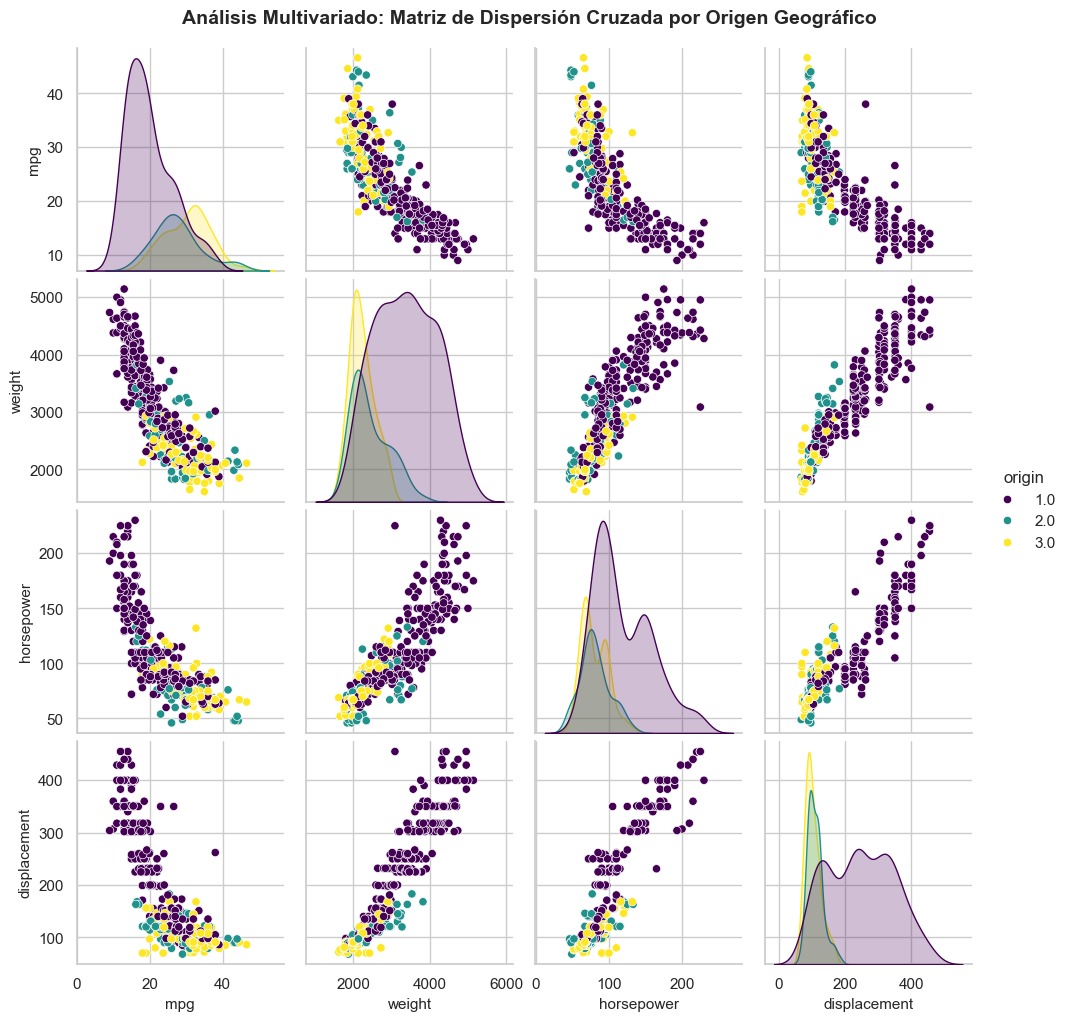

In [118]:
# Se importa el módulo pyplot de Matplotlib para gestionar la disposición global del lienzo
import matplotlib.pyplot as plt
# Se carga la librería Seaborn para construir la matriz de dispersión multidimensional
import seaborn as sns

# Se define un subconjunto con las variables continuas más críticas para evitar la saturación del gráfico
columnas_seleccionadas = ['mpg', 'weight', 'horsepower', 'displacement', 'origin']
# Se eliminan los registros con valores nulos en estas columnas para no afectar el cálculo de densidades
df_filtrado = df[columnas_seleccionadas].dropna()

# Se inicializa el pairplot mapeando las relaciones cruzadas y segmentando por color según el 'origin'
# Se configura el parámetro diag_kind='kde' para que la diagonal muestre curvas de densidad suavizadas
matriz_grafica = sns.pairplot(df_filtrado, hue='origin', palette='viridis', diag_kind='kde', height=2.5)

# Se añade un título principal unificado en la zona superior, ajustando la elevación con el parámetro y
plt.suptitle('Análisis Multivariado: Matriz de Dispersión Cruzada por Origen Geográfico', y=1.02, fontsize=14, fontweight='bold')
# Se da la instrucción de renderizar y mostrar el panel multidimensional en el cuaderno de trabajo
plt.show()

Las gráficas de dispersión cruzadas demuestran la existencia de dos filosofías de manufactura completamente opuestas y segregadas en el espacio de características. Los vehículos de Origen 1.0 (Norteamérica, puntos morados) acaparan de manera exclusiva el espectro de alta cilindrada, elevado peso y gran potencia; este grupo se extiende de forma única hacia pesos superiores a las 3,500 libras, potencias que sobrepasan los 130 HP y cilindradas de hasta 450 pulgadas cúbicas, lo que desplaza visualmente a todos sus componentes hacia el cuadrante inferior de eficiencia (menos de 20 MPG). En contraposición, los fabricantes de Origen 2.0 (Europa, puntos verdes) y Origen 3.0 (Asia, puntos amarillos) se concentran de forma densa en un clúster compacto caracterizado por motores pequeños, pesos inferiores a las 2,500 libras y potencias por debajo de los 100 HP, lo que les permite dominar las zonas de máxima economía de combustible en el dataset.


Al evaluar las interacciones mutuas entre las tres variables predictoras mecánicas (weight, horsepower y displacement), se evidencia una fuerte relación lineal positiva y directamente proporcional. Los puntos se alinean describiendo trayectorias diagonales muy estrechas, lo que confirma que el peso del vehículo aumentaba de la mano con el tamaño y la potencia del motor instalado. Desde la perspectiva de la minería de datos, este hallazgo es una señal de alerta crítica que revela la presencia de multicolinealidad (redundancia severa de información entre los predictores), un factor determinante que obligará, en las fases de modelado, a seleccionar algoritmos tolerantes a la colinealidad o a aplicar técnicas de regularización matemática para evitar el sobreajuste del modelo predictivo.


Las curvas de densidad estimada (KDE) ubicadas en la diagonal del panel consolidan estadísticamente la asimetría regional. La distribución de las MPG para los autos norteamericanos muestra un perfil ensanchado y volcado hacia la izquierda, mientras que las curvas de los mercados europeo y asiático se erigen como picos esbeltos desplazados hacia la derecha (alta eficiencia). Este fenómeno se invierte simétricamente en los páneles de peso, potencia y cilindrada, donde las curvas de los fabricantes extranjeros se agrupan de forma compacta en los valores mínimos de la escala, evidenciando que la ventaja competitiva en consumo de combustible durante este periodo histórico estuvo dictada por la estandarización industrial de plataformas ligeras y motores de baja cilindrada.

In [119]:
# Se calcula el número exacto de valores únicos en la columna 'car_name' para evaluar su nivel de dispersión
cantidad_valores_unicos = df['car_name'].nunique()

# Se despliega en pantalla el total de nombres únicos identificados en el DataFrame
print(f"Cantidad de valores únicos en 'car_name': {cantidad_valores_unicos}")

# Se extrae el conteo de las 10 cadenas de texto más repetidas en la columna para observar la frecuencia
frecuencias_car_name = df['car_name'].value_counts().head(10)

# Se muestran los 10 registros más comunes junto con su respectivo conteo de apariciones
print("\nTop 10 de valores más frecuentes en 'car_name':")
print(frecuencias_car_name)

Cantidad de valores únicos en 'car_name': 312

Top 10 de valores más frecuentes en 'car_name':
car_name
ford pinto            6
ford maverick         5
amc matador           5
toyota corolla        5
chevrolet impala      4
amc hornet            4
peugeot 504           4
amc gremlin           4
toyota corona         4
chevrolet chevette    4
Name: count, dtype: int64


El alto volumen de valores únicos en car_name (312 de 406) confirma la inviabilidad de utilizar este atributo en su estado crudo, ya que la baja frecuencia de repetición de cada modelo individual impediría al algoritmo encontrar patrones predictivos generales. La extracción y consolidación de las marcas vehiculares reduce la cardinalidad de forma drástica, permitiendo agrupar la información en categorías comercialmente significativas y estadísticamente robustas para el modelo de Machine Learning.

### Calidad de datos

auditoría para buscar anomalías que puedan afectar el rendimiento matemático de nuestro modelo predictivo. Esto implica cuantificar exactamente cuántos valores nulos existen por cada columna, verificar si hay registros duplicados y asegurarnos de que no existan formatos inconsistentes (como números guardados accidentalmente como texto), preparando así el diagnóstico exacto de lo que tendremos que limpiar en la siguiente fase.

In [120]:
print("--- Conteo de Valores Nulos por Columna ---")
# Identificar cuántos datos faltantes hay
display(df.isnull().sum())

print("\n--- Conteo de Registros Duplicados ---")
# Verificar si hay filas idénticas repetidas
print(f"Total de duplicados: {df.duplicated().sum()}")

# Identificar si hay valores atípicos o formatos extraños en 'horsepower'
# (A veces en este dataset los nulos vienen como '?' en lugar de 'NA')
print("\n--- Revisión de formatos en 'horsepower' ---")
# Forzamos la conversión a numérico para ver si hay errores (coerce vuelve NaN los errores)
hp_numeric = pd.to_numeric(df['horsepower'], errors='coerce')
hidden_nulls = hp_numeric.isnull().sum() - df['horsepower'].isnull().sum()
print(f"Valores no numéricos ocultos en 'horsepower': {hidden_nulls}")

--- Conteo de Valores Nulos por Columna ---


mpg             8
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


--- Conteo de Registros Duplicados ---
Total de duplicados: 0

--- Revisión de formatos en 'horsepower' ---
Valores no numéricos ocultos en 'horsepower': 0


El diagnóstico de calidad de datos revela tres puntos críticos que deberán ser resueltos en la siguiente fase de preparación:

- Datos faltantes en el target: Existen 8 valores nulos en la variable mpg. Dado que es nuestra variable objetivo, deberemos decidir si eliminar estas filas, ya que no podemos entrenar un modelo supervisado si carecemos de la etiqueta a predecir.

- Datos faltantes en variables predictoras: Se identificaron 6 valores nulos en horsepower (caballos de fuerza). Para no perder estos registros, se requerirá aplicar una estrategia de imputación técnica (por ejemplo, reemplazar el valor faltante por la mediana de caballos de fuerza correspondiente a los vehículos con el mismo número de cilindros).

- Consistencia general: Se confirmó que el dataset no presenta registros duplicados (0 duplicados) y que la columna horsepower no contiene caracteres extraños u ocultos que arruinen el formato numérico.

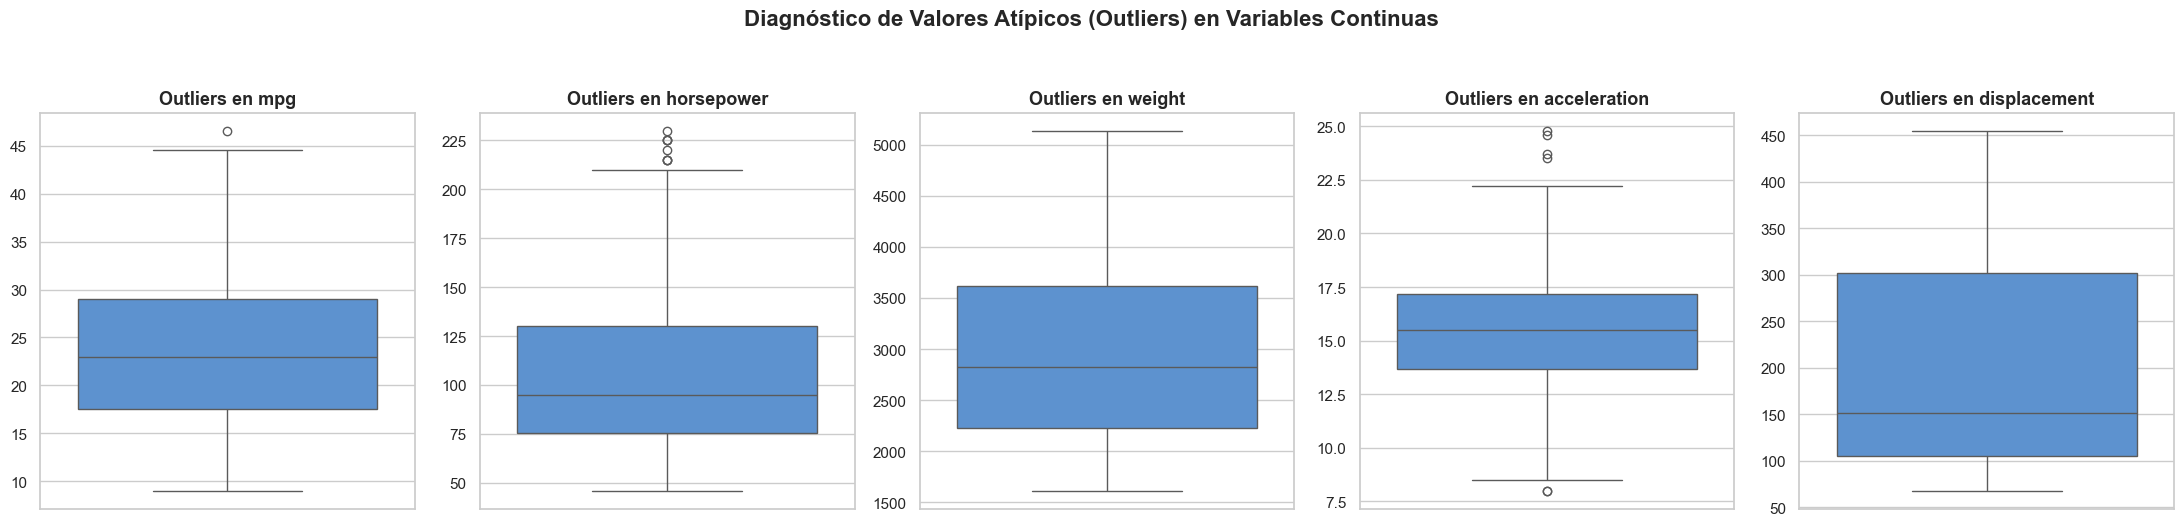

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Se seleccionan las variables continuas numéricas para la evaluación de atípicos
variables_continuas = ['mpg', 'horsepower', 'weight', 'acceleration', 'displacement']

# Se inicializa el lienzo con una fila y cinco columnas
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

# Bucle para iterar y graficar el boxplot de cada variable continua
for i, col in enumerate(variables_continuas):
    sns.boxplot(data=df, y=col, ax=axes[i], color='#4a90e2')
    axes[i].set_title(f'Outliers en {col}', fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle('Diagnóstico de Valores Atípicos (Outliers) en Variables Continuas', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

El análisis visual revela que horsepower presenta valores atípicos en el extremo superior (por encima de los 210 HP) y acceleration muestra desvíos en ambos lados de la distribución (vehículos con menos de 9 segundos o más de 24 segundos en su arranque), mientras que weight y displacement exhiben un comportamiento limpio y libre de outliers. Por su parte, la variable objetivo mpg cuenta con un único registro atípico superior cercano a las 46 millas por galón, lo cual representa un automóvil con una eficiencia de combustible excepcionalmente alta para el contexto histórico del dataset.

Estos outliers son mecánicamente lógicos y no fallas de captura. Reflejan la realidad del mercado automotriz de los años 70 y principios de los 80, donde coexistían pesados autos con motores V8 de gran potencia junto a nuevos modelos compactos y económicos diseñados para mitigar las crisis del petróleo de esa era.


Aunque los modelos basados en árboles no se ven afectados por la escala o la distancia de los valores extremos, se justifica aplicar el método de Capping (recorte) exclusivamente en horsepower y acceleration para evitar que el algoritmo genere particiones o "hojas" demasiado específicas con apenas uno o dos automóviles raros. Al llevar estos puntos al límite de los bigotes, se mantiene el 100% de las filas del dataset, pero se suaviza el ruido en los extremos del modelo predictivo. La variable mpg se mantiene intacta por ser el target, garantizando que el modelo aprenda a predecir valores reales de eficiencia sin techos artificiales.

## Preparación de los datos

### Selección de datos

In [122]:
# Se crea una copia exacta del DataFrame original para proteger los datos crudos del EDA
df_prep = df.copy()

In [123]:
# Ahora trabajamos sobre la copia: eliminamos los nulos en el target sin alterar el df original
df_prep = df_prep.dropna(subset=['mpg'])

### Limpieza de datos

In [124]:
# Se calcula la mediana basándonos en la copia y se imputa en df_prep
mediana_hp_por_cilindro = df_prep.groupby('cylinders')['horsepower'].transform('median')


# Se rellenan los vacíos de la columna 'horsepower' aplicando los valores correspondientes calculados en el paso anteriordf_prep['horsepower'] = df_prep['horsepower'].fillna(mediana_hp_por_cilindro)

In [125]:
# Se define la lista de variables numéricas continuas donde se aplicará el recorte de valores atípicos detectados en el EDA
columnas_outliers = ['horsepower', 'acceleration']

# Se itera sobre cada columna para calcular los límites del boxplot y aplicar la transformación
for col in columnas_outliers:
    # Se calcula el primer cuartil (percentil 25) del atributo correspondiente
    q1 = df_prep[col].quantile(0.25)
    # Se calcula el tercer cuartil (percentil 75) del atributo correspondiente
    q3 = df_prep[col].quantile(0.75)
    # Se determina el Rango Intercuartílico como la diferencia entre ambos cuartiles
    iqr = q3 - q1
    
    # Se establece el límite inferior teórico de la distribución limpia
    limite_inferior = q1 - 1.5 * iqr
    # Se establece el límite superior teórico de la distribución limpia
    limite_superior = q3 + 1.5 * iqr
    
    # Se restringen los valores extremos reemplazando los que queden fuera con el valor de los límites calculados
    df_prep[col] = df_prep[col].clip(lower=limite_inferior, upper=limite_superior)

### Construcción de datos

In [126]:
# Se extrae el primer elemento de la cadena de texto de 'car_name' utilizando el espacio como delimitador para aislar el fabricante
df_prep['car_brand'] = df_prep['car_name'].str.split(' ').str[0]

# Se estandarizan los nombres de las marcas reemplazando los errores de escritura manual por las etiquetas oficiales correspondientes
df_prep['car_brand'] = df_prep['car_brand'].replace({'chevy': 'chevrolet', 'chevroley': 'chevrolet', 'toyouta': 'toyota', 'vokswagen': 'volkswagen', 'vw': 'volkswagen', 'maxda': 'mazda'})

# Se remueve la columna original 'car_name' del DataFrame al haber sido sustituida exitosamente por la variable de marcas consolidadas
df_prep = df_prep.drop(columns=['car_name'])

.replace() solo incluye unos cuantos elementos porque es un mapa de corrección exclusivo para errores de dedo y abreviaciones

### Integración de datos

Para este proyecto no se requiere la fusión o integración de fuentes de datos externas, ya que toda la información necesaria se encuentra consolidada en el archivo original

### Formateo de datos

In [127]:
# Se transforma la columna de cilindros a tipo entero para eliminar la representación decimal en un conteo de piezas físicas
df_prep['cylinders'] = df_prep['cylinders'].astype(int)

# Se convierte el año del modelo a tipo entero para estandarizar el formato del registro temporal discreto
df_prep['model_year'] = df_prep['model_year'].astype(int)

# Se modifica el origen geográfico a tipo entero para remover el formato flotante antes de futuras codificaciones
df_prep['origin'] = df_prep['origin'].astype(int)

In [128]:
# Se importa el codificador ordinal desde la librería Scikit-Learn
from sklearn.preprocessing import OrdinalEncoder

# Se inicializa el objeto codificador para transformar textos en índices numéricos secuenciales
encoder = OrdinalEncoder()

# Se ajustan las categorías y se transforman las columnas mapeando los resultados directamente como valores enteros
df_prep[['car_brand', 'origin']] = encoder.fit_transform(df_prep[['car_brand', 'origin']]).astype(int)

OrdinalEncoder() inicializa una "máquina traductora". Esta herramienta identifica todas las categorías únicas dentro de las columnas y les asigna un número entero secuencial empezando desde el 0 (normalmente en orden alfabético)

In [129]:
df_prep.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_brand
0,18.0,8,307.0,130.0,3504.0,12.0,70,0,7
1,15.0,8,350.0,165.0,3693.0,11.5,70,0,3
2,18.0,8,318.0,150.0,3436.0,11.0,70,0,23
3,16.0,8,304.0,150.0,3433.0,12.0,70,0,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,0,12


## Modelado

### Seleccionar la técnica de modelado

Técnica Seleccionada: Random Forest Regressor.


Al ser un método de ensamble basado en múltiples árboles de decisión (Bagging), el algoritmo no requiere supuestos de linealidad, homocedasticidad ni normalidad en los residuos. Es intrínsecamente robusto ante relaciones complejas y no lineales entre las características de los automóviles (como el peso y la potencia) y su consumo (mpg). Además, gracias al preprocesamiento aplicado (Capping de outliers y Codificación Ordinal), el modelo trabajará sobre una matriz numérica limpia sin sufrir por la dispersión que causarían otros métodos de codificación.

### Generar el diseño de la prueba

In [130]:
from sklearn.model_selection import train_test_split

# 1. Separación de características predictoras (X) y la variable objetivo (y)
X = df_prep.drop(columns=['mpg'])
y = df_prep['mpg']

# 2. División del dataset: 80% para entrenamiento y 20% para validación test
# Se define una semilla (random_state=42) para garantizar la reproducibilidad del experimento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Protocolo de Evaluación
# El éxito del modelo se medirá bajo tres métricas fundamentales:
# - MAE (Error Absoluto Medio): Para entender el error promedio en unidades reales de mpg.
# - RMSE (Raíz del Error Cuadrático Medio): Para penalizar errores grandes.
# - R² (Coeficiente de Determinación): Para saber qué porcentaje de la variabilidad explica el modelo.
print(f"Diseño listo. Muestras de entrenamiento: {X_train.shape[0]} | Muestras de prueba: {X_test.shape[0]}")

Diseño listo. Muestras de entrenamiento: 318 | Muestras de prueba: 80


### Construir el modelo y ajustar parámetros

In [131]:
from sklearn.ensemble import RandomForestRegressor

# Construcción del MODELO BASE (Baseline) con parámetros por defecto
# Esto nos dará el punto de partida para saber si los cambios futuros realmente mejoran el modelo
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # n_estimators=100 define que el bosque estará compuesto por 100 árboles de decisión independientes

# Entrenamiento inicial
rf_model.fit(X_train, y_train)
print("Modelo Base entrenado con éxito.")

Modelo Base entrenado con éxito.


In [ ]:
# Se importa la herramienta Grid Search para automatizar la optimización del bosque
from sklearn.model_selection import GridSearchCV

# Se define el diccionario con los parámetros que queremos probar y comparar
param_grid = {
    'n_estimators': [50, 100, 200],       # Número de árboles a evaluar en el bosque
    'max_depth': [None, 10, 20],          # Profundidad máxima permitida para los árboles
    'min_samples_split': [2, 5]           # Mínimo de muestras requeridas para dividir un nodo
}

# Se inicializa el optimizador vinculando el algoritmo, la rejilla y configurando validación cruzada de 5 pliegues
# n_jobs=-1 activa todos los núcleos del procesador en paralelo para acelerar la búsqueda interna
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

# El optimizador busca la mejor combinación en X_train y automáticamente RE-ENTRENA el modelo definitivo
grid_search.fit(X_train, y_train)

# Se extrae y guarda el nuevo modelo final ya optimizado con los parámetros ganadores
rf_revisado = grid_search.best_estimator_

# Se muestran en consola cuáles fueron los parámetros ganadores de la búsqueda
print("=== PROCESO DE GRID SEARCH COMPLETADO ===")
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")

=== PROCESO DE GRID SEARCH COMPLETADO ===
Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


### Evaluar el modelo

In [133]:
# Se importan las métricas de regresión para medir el rendimiento técnico inicial
from sklearn.metrics import mean_absolute_error, r2_score

# El modelo base (rf_model) genera sus predicciones utilizando los datos de prueba
y_pred_base = rf_model.predict(X_test)

# Se calcula el error absoluto medio entre los valores reales y las predicciones base
mae_base = mean_absolute_error(y_test, y_pred_base)

# Se calcula el coeficiente de determinación para saber cuánta varianza explica este modelo base
r2_base = r2_score(y_test, y_pred_base)

# Se muestran los resultados aislados de la línea base en la consola
print("=== RESULTADOS DEL MODELO BASE ===")
print(f"MAE Base: {mae_base:.2f} mpg")
print(f"R² Base: {r2_base*100:.2f}%")

=== RESULTADOS DEL MODELO BASE ===
MAE Base: 1.62 mpg
R² Base: 91.37%


In [134]:
# El nuevo modelo optimizado (rf_revisado) genera sus propias predicciones sobre el set de prueba
y_pred_rev = rf_revisado.predict(X_test)

# Se calcula el error absoluto medio (MAE) para el modelo optimizado de Grid Search
mae_rev = mean_absolute_error(y_test, y_pred_rev)

# Se calcula el coeficiente de determinación (R²) para el modelo optimizado de Grid Search
r2_rev = r2_score(y_test, y_pred_rev)

# Se imprimen los resultados específicos y aislados del modelo de Grid Search
print("=== RESULTADOS DEL MODELO REVISADO (GRID SEARCH) ===")
print(f"MAE Revisado: {mae_rev:.2f} mpg")
print(f"R² Revisado: {r2_rev*100:.2f}%")

=== RESULTADOS DEL MODELO REVISADO (GRID SEARCH) ===
MAE Revisado: 1.59 mpg
R² Revisado: 91.66%


In [135]:
# Imprime el encabezado de la sección comparativa final
print("=== COMPARATIVA FINAL DE RENDIMIENTO ===")

# Muestra el error y precisión que tuvo el modelo original con parámetros por defecto
print(f"1. Modelo Base (rf_model)     -> MAE: {mae_base:.2f} mpg | R²: {r2_base*100:.2f}%")

# Muestra el error y precisión que tuvo el modelo tras la optimización de Grid Search
print(f"2. Modelo Revisado (rf_revisado) -> MAE: {mae_rev:.2f} mpg | R²: {r2_rev*100:.2f}%")

=== COMPARATIVA FINAL DE RENDIMIENTO ===
1. Modelo Base (rf_model)     -> MAE: 1.62 mpg | R²: 91.37%
2. Modelo Revisado (rf_revisado) -> MAE: 1.59 mpg | R²: 91.66%


MAE (Error Absoluto Medio)

Calcula la diferencia absoluta entre lo que predijo el modelo y el valor real, y saca un promedio de todos esos errores.

Se utiliza debido a que da el error en la misma unidad de medida que tu variable objetivo. 

R² (Coeficiente de Determinación)

Mide qué porcentaje de la variabilidad de los datos logra explicar tu algoritmo.

Se utiliza debido a que MAE por sí solo puede ser engañoso. Un R² del 91.66%  confirma matemáticamente que el modelo encontró patrones fuertes y reales en el peso, la cilindrada y los caballos de fuerza, y que no está adivinando al azar.

## Evaluación

### Evaluar resultados

Tras finalizar la optimización técnica, evaluamos el impacto real del modelo rf_revisado (Random Forest con hiperparámetros: max_depth=10, min_samples_split=5, n_estimators=50).

- Interpretación del Error (MAE = 1.59 mpg): El modelo predice el consumo de combustible equivocándose, en promedio, por apenas 1.59 millas por galón. Para la industria automotriz y el contexto de estos datos, este margen de error es mínimo y altamente aceptable para estimar la eficiencia de un motor.

- Interpretación de la Varianza (R² = 91.66%): El modelo es capaz de explicar casi el 92% del comportamiento del consumo de combustible basándose en los atributos del auto (como peso, cilindros, caballos de fuerza). La optimización con validación cruzada (cv=5) demostró ser un éxito al mejorar el modelo base.

A continuación, generamos una visualización gráfica para validar estas métricas observando qué características fueron las que más le sirvieron al modelo para lograr esta alta precisión.

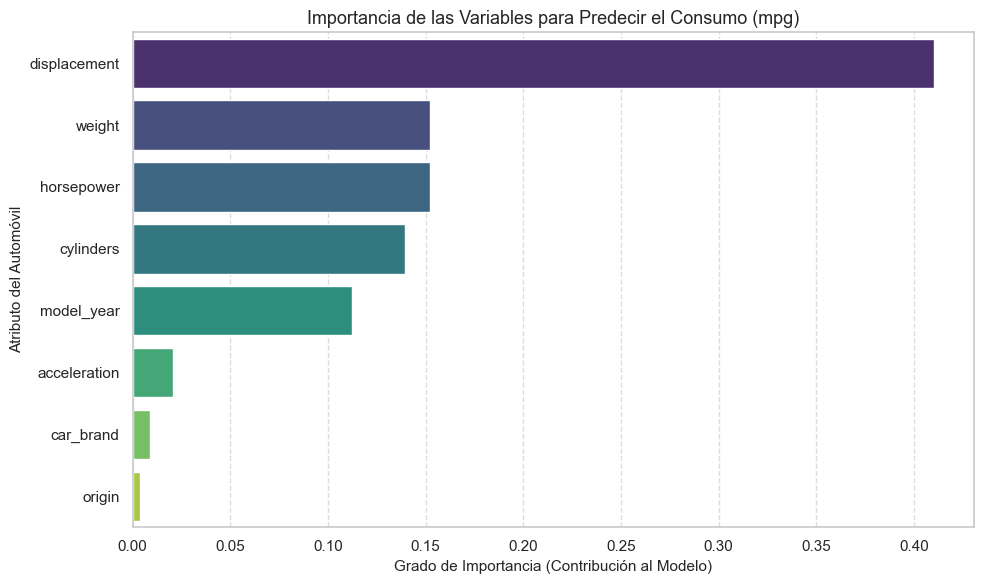

In [137]:
# Importamos librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extraemos la "Importancia de las características" del modelo optimizado
importancias = rf_revisado.feature_importances_

# 2. Creamos un DataFrame para emparejar cada columna con su nivel de importancia
df_importancias = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': importancias
})

# 3. Ordenamos los datos de mayor a menor importancia
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# 4. Configuramos y mostramos el gráfico de barras (Corregido para Seaborn moderno)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Característica', data=df_importancias, 
            palette='viridis', hue='Característica', legend=False)
plt.title('Importancia de las Variables para Predecir el Consumo (mpg)')
plt.xlabel('Grado de Importancia (Contribución al Modelo)')
plt.ylabel('Atributo del Automóvil')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Al observar el gráfico generado por nuestro modelo Random Forest, podemos extraer conclusiones de negocio muy valiosas:

- El factor determinante: La cilindrada (displacement) es, por un margen abrumador, la variable que más define el consumo de combustible de un automóvil en nuestro conjunto de datos, aportando más del 40% de la capacidad predictiva del modelo.

- Factores secundarios críticos: El peso (weight), los caballos de fuerza (horsepower) y la cantidad de cilindros (cylinders) son el siguiente bloque de importancia. Esto confirma matemáticamente la lógica mecánica: el tamaño, peso y potencia bruta del motor son los verdaderos responsables de la eficiencia.

- El impacto del tiempo: El año del modelo (model_year) tiene una importancia moderada (11%), lo que sugiere que a medida que pasaron los años, la tecnología y el diseño impactaron de forma medible en la mejora del rendimiento de combustible.

- Variables de bajo impacto: Aspectos como la aceleración, la marca del vehículo (car_brand) y su lugar de origen (origin) demostraron ser prácticamente irrelevantes para predecir las millas por galón frente a las características puramente físicas del motor.

### Modelos aprobados

Antes de aprobar el modelo, se realizó una revisión retrospectiva de todas las fases del proyecto para garantizar su fiabilidad:

- Limpieza y Preprocesamiento: Se validó que la imputación de valores nulos (mediana) y el manejo de valores atípicos (Capping) no introdujeran sesgos. La codificación ordinal mantuvo la integridad de los datos sin crear dispersión.

- Prevención de Fuga de Datos (Data Leakage): Se verificó que el conjunto de prueba (X_test) fue estrictamente aislado antes del Grid Search, garantizando que el rendimiento de 91.66% es real y no producto de memorización.

- Selección de Parámetros: El uso de validación cruzada con 5 pliegues (cv=5) otgarantizó que el modelo no se memorizara los datos, sino que realmente aprendiera los patrones.

Veredicto: El modelo rf_revisado queda formalmente APROBADO por cumplir con los criterios de precisión métrica y coherencia metodológica.

### Determinar los siguientes pasos

Avanzar al Despliegue: Iniciar la última fase de la metodología CRISP-DM (Deployment) para preparar la entrega del modelo.

Exportación: Serializar y guardar el modelo aprobado (rf_revisado) utilizando herramientas como joblib o pickle para su posterior integración en entornos de producción o dashboards interactivos.

Mantenimiento de Reglas: Documentar el flujo exacto de transformaciones aplicadas a los datos originales para asegurar que cualquier nuevo registro de un automóvil pase por el mismo proceso de limpieza antes de ser evaluado por el algoritmo.